In [4]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats
from tqdm.notebook import tqdm

In [5]:
CLEAN_ROOT = Path('../../data/cmhc-rental-clean')
REF_ROOT   = Path('../../data/reference')
REF_ROOT.mkdir(parents=True, exist_ok=True)

# ── CPI, all-items, 2002=100 (Statistics Canada) ─────────────────────────
CPI_YEARS  = list(range(1990, 2026))
CPI_VALUES = [
    78.7,  82.4,  83.2,  84.7,  84.7,  86.8,  88.2,  89.8,  90.6,  92.4,
    95.1,  98.0, 100.0, 102.7, 104.6, 106.9, 108.8, 110.8, 113.3, 113.7,
   116.5, 120.1, 121.8, 123.0, 125.9, 127.4, 129.7, 131.9, 135.0, 137.5,
   138.4, 143.2, 152.9, 158.7, 162.5, 165.6,
]

# ── Ontario rent-control guideline (annual max % increase) ───────────────
# No entry for 1990 — that is the base year (no prior-year to compound from).
RENT_CONTROL = {
    1991: 5.4, 1992: 6.0, 1993: 4.9, 1994: 3.2, 1995: 2.9,
    1996: 2.8, 1997: 2.8, 1998: 3.0, 1999: 3.0, 2000: 2.6,
    2001: 2.9, 2002: 3.9, 2003: 2.9, 2004: 2.9, 2005: 1.5,
    2006: 2.1, 2007: 2.6, 2008: 1.4, 2009: 1.8, 2010: 2.1,
    2011: 0.7, 2012: 3.1, 2013: 2.5, 2014: 0.8, 2015: 1.6,
    2016: 2.0, 2017: 1.5, 2018: 1.8, 2019: 1.8, 2020: 2.2,
    2021: 0.0, 2022: 1.2, 2023: 2.5, 2024: 2.5, 2025: 2.5,
}

# ── Ontario population, Q1 estimates (Statistics Canada) ─────────────────
POP_Q1 = {
    1990: 10_189_985, 1991: 10_355_101, 1992: 10_488_022, 1993: 10_629_994,
    1994: 10_744_762, 1995: 10_875_308, 1996: 11_009_307, 1997: 11_146_270,
    1998: 11_292_059, 1999: 11_419_589, 2000: 11_576_994, 2001: 11_771_945,
    2002: 11_979_906, 2003: 12_155_691, 2004: 12_303_516, 2005: 12_444_755,
    2006: 12_587_149, 2007: 12_703_327, 2008: 12_814_686, 2009: 12_932_742,
    2010: 13_059_426, 2011: 13_199_081, 2012: 13_325_337, 2013: 13_446_276,
    2014: 13_563_311, 2015: 13_657_423, 2016: 13_774_364, 2017: 13_975_516,
    2018: 14_199_811, 2019: 14_449_986, 2020: 14_718_155, 2021: 14_761_811,
    2022: 14_947_417, 2023: 15_305_369, 2024: 15_823_956, 2025: 16_191_372,
}

# ── Ontario median total income — economic families + unattached individuals
# Source: Statistics Canada. No 2025 data yet.
INCOME_YEARS   = list(range(1990, 2025))
INCOME_ONTARIO = [
    39955, 38335, 39219, 38623, 38675, 39634, 39731, 40451, 42317, 45205,
    47696, 49271, 49969, 51950, 52590, 54864, 55706, 56866, 59265, 57655,
    58716, 59791, 61162, 60402, 64693, 64915, 66007, 69400, 73357, 73023,
    78782, 81954, 83272, 88384, 90200,
]

# ── Analysis periods (seven-year chunks) ─────────────────────────────────
PERIODS = [
    (1990, 1997),
    (1997, 2004),
    (2004, 2011),
    (2011, 2018),
    (2018, 2025),
]

BASE_YEAR  = 1990
INDEX_BASE = 1000

# ── Chart style (reference palette) ──────────────────────────────────────
C1 = '#2a78d6'  # blue   — rent
C2 = '#1baf7a'  # aqua   — CPI
C3 = '#eda100'  # yellow — rent control
C4 = '#008300'  # green  — population
C5 = '#4a3aa7'  # violet — income
C6 = '#e34948'  # red    — rental units stock

SURFACE  = '#fcfcfb'
INK      = '#0b0b0b'
INK2     = '#52514e'
MUTED    = '#898781'
GRID_CLR = '#e1e0d9'

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.edgecolor':    GRID_CLR,
    'axes.labelcolor':   INK2,
    'xtick.color':       INK2,
    'ytick.color':       INK2,
    'grid.color':        GRID_CLR,
    'grid.linewidth':    0.5,
    'figure.facecolor':  SURFACE,
    'axes.facecolor':    SURFACE,
})

## Section 1 — Reference Data

Persist CPI, rent-control guideline, and Ontario population series to
`data/reference/` so other notebooks can load them without re-entering raw values.
Population uses Q1 estimates; CPI is annual all-items; rent control is the Ontario
annual guideline maximum.

In [ ]:
pd.DataFrame({'Year': CPI_YEARS, 'CPI': CPI_VALUES}).to_csv(
    REF_ROOT / 'cpi_ontario.csv', index=False)

pd.DataFrame(sorted(RENT_CONTROL.items()), columns=['Year', 'Guideline_Pct']).to_csv(
    REF_ROOT / 'rent_control_ontario.csv', index=False)

pd.DataFrame(sorted(POP_Q1.items()), columns=['Year', 'Population']).to_csv(
    REF_ROOT / 'population_ontario_q1.csv', index=False)

pd.DataFrame({'Year': INCOME_YEARS, 'Median_Income': INCOME_ONTARIO}).to_csv(
    REF_ROOT / 'income_ontario.csv', index=False)

for f in sorted(REF_ROOT.glob('*.csv')):
    print(f.name)

cpi_canada.csv
income_ontario.csv
population_ontario_q1.csv
rent_control_ontario.csv


## Section 2A — Rent vs. Economic Benchmarks (Indexed to 1000, base 1990)

Rescaling everything to 1000 in 1990 lets us compare growth rates directly across
series with very different units (dollars, index points, nominal income).

**Rent control** is compounded annually from 1990 using the guideline rate — it
shows what rent *would* be today if it had risen exactly at the allowed maximum
every year since 1990.  Note that rent control only applies to units built before
November 2018, and vacant-unit turnover can reset rents to market.

**Income** is median total income for economic families and unattached individuals
in Ontario (Statistics Canada); 2025 data not yet published.

In [7]:
ontario = pd.read_csv(
    CLEAN_ROOT / 'can-pr-primary/primary-summary/ontario.csv'
).set_index('Year')

# Rent: direct ratio to base year
rent_idx = INDEX_BASE * ontario['Average Rent'] / ontario.loc[BASE_YEAR, 'Average Rent']

# CPI: direct ratio to base year
cpi_s   = pd.Series(CPI_VALUES, index=CPI_YEARS)
cpi_idx = INDEX_BASE * cpi_s / cpi_s[BASE_YEAR]

# Rent control: cumulative compound from 1990
rc_idx = pd.Series(index=range(BASE_YEAR, 2026), dtype=float)
rc_idx[BASE_YEAR] = INDEX_BASE
for yr in range(BASE_YEAR + 1, 2026):
    rc_idx[yr] = rc_idx[yr - 1] * (1 + RENT_CONTROL.get(yr, 0.0) / 100)

# Population: direct ratio to base year
pop_s   = pd.Series(POP_Q1).sort_index()
pop_idx = INDEX_BASE * pop_s / pop_s[BASE_YEAR]

# Median income: direct ratio to base year (ends 2024 — no 2025 data yet)
income_s   = pd.Series(INCOME_ONTARIO, index=INCOME_YEARS)
income_idx = INDEX_BASE * income_s / income_s[BASE_YEAR]

# Primary rental units stock: direct ratio to base year
units_s   = ontario['Units']
units_idx = INDEX_BASE * units_s / units_s[BASE_YEAR]

benchmark = pd.DataFrame({
    'Rent (Ontario)':  rent_idx,
    'CPI':             cpi_idx,
    'Rent Control':    rc_idx,
    'Population (ON)': pop_idx,
    'Income (ON)':     income_idx,
    'Rental Units':    units_idx,
}).loc[1990:2025]

benchmark.tail(3)

,Rent (Ontario),CPI,Rent Control,Population (ON),Income (ON),Rental Units
2023,2793.402778,2016.518424,2251.234071,1502.001132,2212.088600,1109.849065
2024,2892.361111,2064.803050,2307.514923,1552.892963,2257.539732,1150.071193
2025,3003.472222,2104.193139,2365.202796,1588.949542,NaN,1165.738297


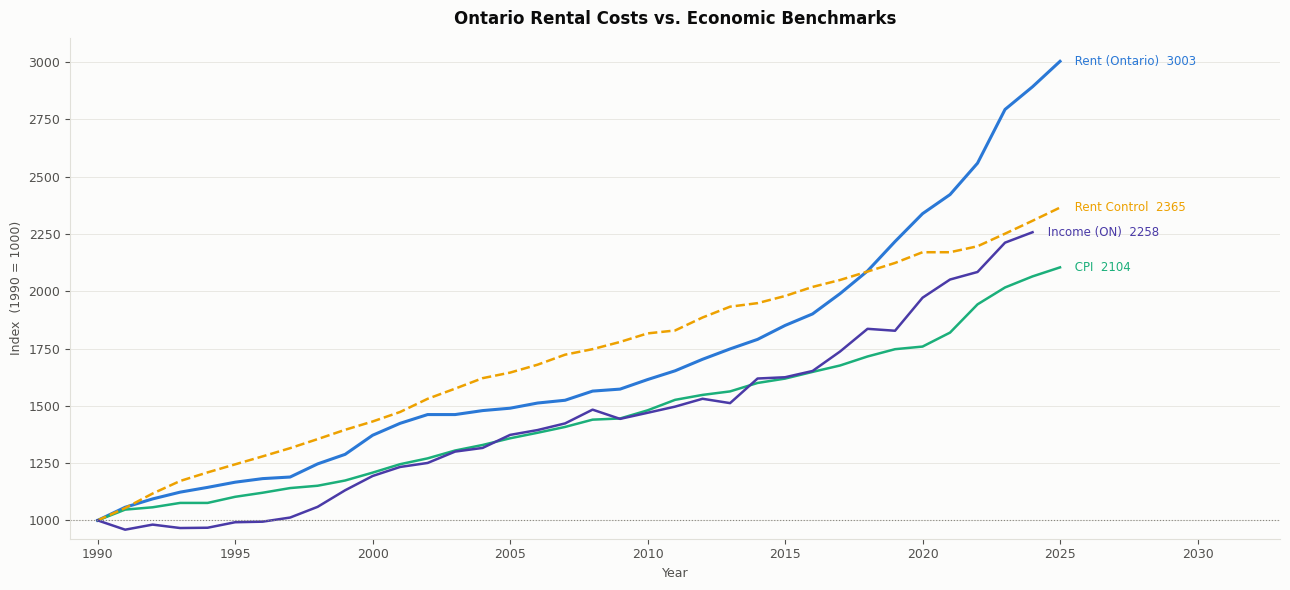

In [8]:
ECON_SERIES = {
    'Rent (Ontario)': dict(color=C1, linestyle='solid',  linewidth=2.2),
    'CPI':            dict(color=C2, linestyle='solid',  linewidth=1.8),
    'Rent Control':   dict(color=C3, linestyle='dashed', linewidth=1.8),
    'Income (ON)':    dict(color=C5, linestyle='solid',  linewidth=1.8),
}

fig, ax = plt.subplots(figsize=(13, 6))

for label, style in ECON_SERIES.items():
    series = benchmark[label].dropna()
    ax.plot(series.index, series, **style)

for label, style in ECON_SERIES.items():
    series = benchmark[label].dropna()
    val = series.iloc[-1]
    ax.text(series.index[-1] + 0.4, val, f' {label}  {val:.0f}',
            color=style['color'], va='center', fontsize=8.5)

ax.axhline(INDEX_BASE, color=MUTED, linewidth=0.8, linestyle=':')
ax.set_xlim(1989, 2033)
ax.set_ylim(bottom=920)
ax.set_xlabel('Year', fontsize=9)
ax.set_ylabel('Index  (1990 = 1000)', fontsize=9)
ax.set_title('Ontario Rental Costs vs. Economic Benchmarks', fontsize=12,
             fontweight='bold', color=INK, pad=10)
ax.grid(axis='y')
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

In [9]:
# ── Section 2A: correlations with average rent ───────────────────────────────
# Align all indexed series on common years (income ends 2024)
common_2a = benchmark[['Rent (Ontario)', 'CPI', 'Rent Control', 'Income (ON)']].dropna()
# YoY % changes remove the shared upward trend and are the more meaningful measure
bench_yoy = common_2a.pct_change().dropna() * 100

print('Section 2A — Correlation with Ontario Average Rent')
print('─' * 70)
print(f'  {"Series":<18}  {"Level r":>8}  {"Level p":>8}  {"YoY r":>7}  {"YoY p":>8}  {"YoY ρ":>7}  n')
print('─' * 70)
for col in ['CPI', 'Rent Control', 'Income (ON)']:
    r_lv, p_lv = stats.pearsonr(common_2a['Rent (Ontario)'], common_2a[col])
    r_yy, p_yy = stats.pearsonr(bench_yoy['Rent (Ontario)'],  bench_yoy[col])
    r_sp, _    = stats.spearmanr(bench_yoy['Rent (Ontario)'], bench_yoy[col])
    n_yy = int(bench_yoy[['Rent (Ontario)', col]].dropna().shape[0])
    print(f'  {col:<18}  {r_lv:+8.3f}  {p_lv:8.4f}  {r_yy:+7.3f}  {p_yy:8.4f}  {r_sp:+7.3f} {n_yy:>3}')
print()
print('Note: level correlations are inflated by the shared upward trend in all series.')
print('YoY % changes (columns 5–7) are the more informative association measure.')

Section 2A — Correlation with Ontario Average Rent
──────────────────────────────────────────────────────────────────────
  Series               Level r   Level p    YoY r     YoY p    YoY ρ  n
──────────────────────────────────────────────────────────────────────
  CPI                   +0.981    0.0000   +0.397    0.0200   +0.261  34
  Rent Control          +0.936    0.0000   +0.022    0.9023   -0.025  34
  Income (ON)           +0.987    0.0000   +0.273    0.1188   +0.272  34

Note: level correlations are inflated by the shared upward trend in all series.
YoY % changes (columns 5–7) are the more informative association measure.


## Section 2B — Rent, Population & Rental Stock

Three independent y-axes on the same time axis — left (blue) is average rent in
raw dollars, centre-right (green) is Ontario population in millions, far-right (red)
is total primary rental units in thousands.

The goal is to visualise the supply-demand dynamic: population is a rough demand
proxy; rental units is the supply side.  Rent is shown in nominal dollars so
directional divergences between the three series are immediately visible.

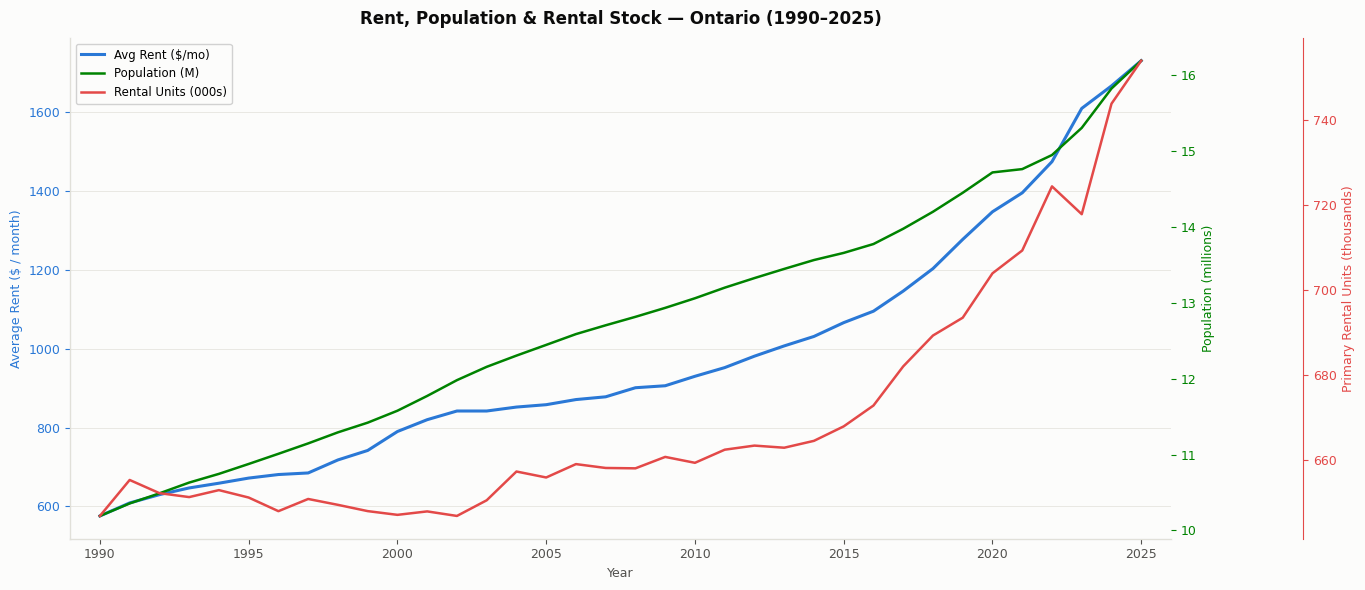

In [10]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# Offset the third spine so it doesn't overlap ax2
ax3.spines['right'].set_position(('axes', 1.12))
ax3.spines['right'].set_visible(True)
ax3.spines['right'].set_color(C6)

pop_raw   = pop_s.loc[1990:2025]
units_raw = ontario['Units'].loc[1990:2025]
rent_raw  = ontario['Average Rent'].loc[1990:2025]

l1, = ax1.plot(rent_raw.index,  rent_raw,          color=C1, linewidth=2.2, label='Avg Rent ($/mo)')
l2, = ax2.plot(pop_raw.index,   pop_raw  / 1e6,    color=C4, linewidth=1.8, label='Population (M)')
l3, = ax3.plot(units_raw.index, units_raw / 1e3,   color=C6, linewidth=1.8, label='Rental Units (000s)')

ax1.set_ylabel('Average Rent ($ / month)', color=C1, fontsize=9)
ax2.set_ylabel('Population (millions)',    color=C4, fontsize=9)
ax3.set_ylabel('Primary Rental Units (thousands)', color=C6, fontsize=9)

ax1.tick_params(axis='y', colors=C1, labelsize=9)
ax2.tick_params(axis='y', colors=C4, labelsize=9)
ax3.tick_params(axis='y', colors=C6, labelsize=9)
ax1.tick_params(axis='x', labelsize=9)
ax1.set_xlabel('Year', fontsize=9)
ax1.set_xlim(1989, 2026)

lines  = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=8.5, framealpha=0.88)

ax1.set_title('Rent, Population & Rental Stock — Ontario (1990–2025)',
              fontsize=12, fontweight='bold', color=INK, pad=10)
ax1.grid(axis='y', color=GRID_CLR, linewidth=0.5)

plt.tight_layout()
fig.subplots_adjust(right=0.84)   # make room for the offset third spine
plt.show()

In [11]:
# ── Section 2B: correlations with average rent ───────────────────────────────
common_2b = pd.DataFrame({
    'Rent':  ontario['Average Rent'].loc[1990:2025],
    'Pop':   pop_s.loc[1990:2025],
    'Units': ontario['Units'].loc[1990:2025],
}).dropna()
b2_yoy = common_2b.pct_change().dropna() * 100

print('Section 2B — Correlation with Ontario Average Rent (raw levels)')
print('─' * 70)
print(f'  {"Series":<18}  {"Level r":>8}  {"Level p":>8}  {"YoY r":>7}  {"YoY p":>8}  {"YoY ρ":>7}  n')
print('─' * 70)
for col, label in [('Pop', 'Population (ON)'), ('Units', 'Rental Units')]:
    r_lv, p_lv = stats.pearsonr(common_2b['Rent'], common_2b[col])
    r_yy, p_yy = stats.pearsonr(b2_yoy['Rent'],    b2_yoy[col])
    r_sp, _    = stats.spearmanr(b2_yoy['Rent'],   b2_yoy[col])
    print(f'  {label:<18}  {r_lv:+8.3f}  {p_lv:8.4f}  {r_yy:+7.3f}  {p_yy:8.4f}  {r_sp:+7.3f} {len(b2_yoy):>3}')
print()
print('Note: level r ≈ 1 for population and units because all three trend upward together.')
print('YoY % changes test whether acceleration/deceleration in supply or population')
print('tracks contemporaneous acceleration/deceleration in rent.')

Section 2B — Correlation with Ontario Average Rent (raw levels)
──────────────────────────────────────────────────────────────────────
  Series               Level r   Level p    YoY r     YoY p    YoY ρ  n
──────────────────────────────────────────────────────────────────────
  Population (ON)       +0.970    0.0000   +0.426    0.0107   +0.494  35
  Rental Units          +0.955    0.0000   +0.135    0.4380   +0.248  35

Note: level r ≈ 1 for population and units because all three trend upward together.
YoY % changes test whether acceleration/deceleration in supply or population
tracks contemporaneous acceleration/deceleration in rent.


## Section 3A — Supply and Rent: Ontario Level (Year-over-Year)

Each dot is one year (1991–2025). x = year-over-year % change in primary rental
units; y = year-over-year % change in average rent.  Dots shade from light to dark
as years approach the present.  If the supply-suppresses-rent thesis held, we would
expect a negative slope.

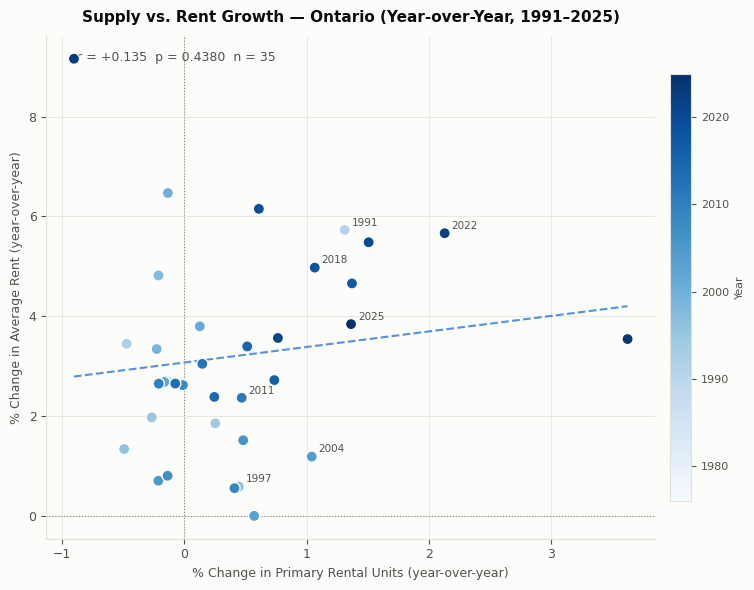

In [12]:
# Year-over-year % change in units and average rent
yoy = pd.DataFrame({
    'pct_rent':  ontario['Average Rent'].pct_change() * 100,
    'pct_units': ontario['Units'].pct_change() * 100,
}).dropna()  # drops 1990 (no prior year)

slope, intercept, r, p, _ = stats.linregress(yoy['pct_units'], yoy['pct_rent'])

fig, ax = plt.subplots(figsize=(8, 6))

# vmin offset so the earliest years are still a visible blue (not near-white)
sc = ax.scatter(yoy['pct_units'], yoy['pct_rent'],
                c=yoy.index, cmap='Blues',
                vmin=yoy.index.min() - 15, vmax=yoy.index.max(),
                s=65, zorder=5, edgecolors=SURFACE, linewidths=1.0)

# Regression line
xfit = np.linspace(yoy['pct_units'].min(), yoy['pct_units'].max(), 100)
ax.plot(xfit, slope * xfit + intercept,
        color=C1, linewidth=1.5, linestyle='--', alpha=0.8)

# Year labels for notable points
for yr in [1991, 1997, 2004, 2011, 2018, 2022, 2025]:
    if yr in yoy.index:
        ax.annotate(str(yr),
                    (yoy.loc[yr, 'pct_units'], yoy.loc[yr, 'pct_rent']),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=7.5, color=INK2)

p_str = f'p = {p:.4f}' if p >= 0.0001 else 'p < 0.0001'
ax.text(0.05, 0.97, f'r = {r:+.3f}  {p_str}  n = {len(yoy)}',
        transform=ax.transAxes, va='top', fontsize=9, color=INK2)

cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label('Year', fontsize=8, color=INK2)
cbar.ax.tick_params(labelsize=8, colors=INK2)

ax.axhline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.set_xlabel('% Change in Primary Rental Units (year-over-year)', fontsize=9)
ax.set_ylabel('% Change in Average Rent (year-over-year)', fontsize=9)
ax.set_title('Supply vs. Rent Growth — Ontario (Year-over-Year, 1991–2025)',
             fontsize=11, fontweight='bold', color=INK, pad=10)
ax.grid()
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()


In [13]:
# ── Section 3A: summary statistics ───────────────────────────────────────────
_, _, _, _, se_a = stats.linregress(yoy['pct_units'], yoy['pct_rent'])
r_sp_a, p_sp_a  = stats.spearmanr(yoy['pct_units'], yoy['pct_rent'])
tc_a = stats.t.ppf(0.975, df=len(yoy) - 2)

print('Section 3A — % Change in Units vs % Change in Rent (Ontario YoY)')
print(f'  Pearson  r = {r:+.3f}  p = {p:.4f}  n = {len(yoy)}')
print(f'  Spearman ρ = {r_sp_a:+.3f}  p = {p_sp_a:.4f}')
print(f'  OLS slope  = {slope:+.3f} pp rent per 1 pp supply change')
print(f'               95% CI [{slope - tc_a * se_a:+.3f},  {slope + tc_a * se_a:+.3f}]')

Section 3A — % Change in Units vs % Change in Rent (Ontario YoY)
  Pearson  r = +0.135  p = 0.4380  n = 35
  Spearman ρ = +0.248  p = 0.1501
  OLS slope  = +0.311 pp rent per 1 pp supply change
               95% CI [-0.495,  +1.118]


## Section 3B — Demand-Adjusted Supply vs. Rent (Population-Normalised)

Same year-over-year scatter as 3A, but the x-axis now controls for population growth:
x = change in primary rental units *per 1,000 Ontario residents* that year.

This removes the confound that supply additions look bigger in absolute terms as the
province grows.  A flat or positive slope here still contradicts the simple
supply-suppresses-rent thesis even after accounting for demand growth.

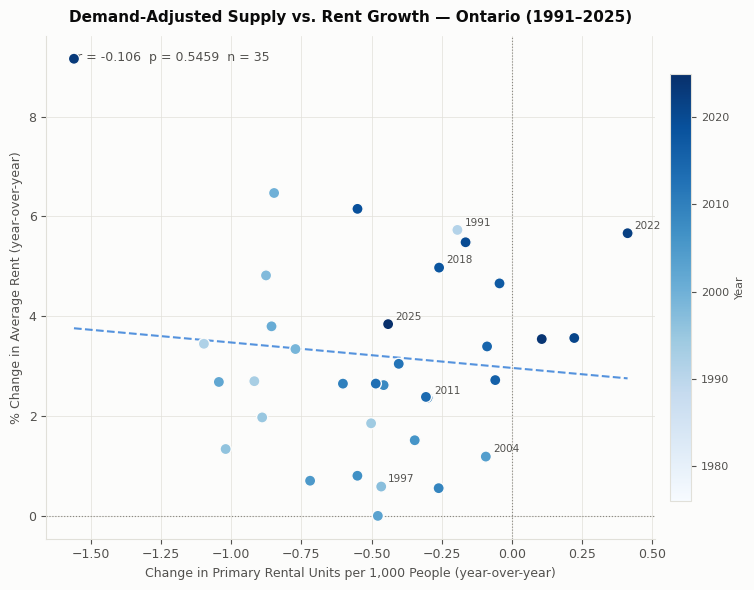

In [14]:
pop_s_b = pd.Series(POP_Q1).sort_index()

# Supply density: rental units per 1,000 Ontario residents
units_per_1k = ontario['Units'] / (pop_s_b / 1_000)

yoy_b = pd.DataFrame({
    'pct_rent':           ontario['Average Rent'].pct_change() * 100,
    'delta_units_per_1k': units_per_1k.diff(),   # absolute year-over-year change in density
}).dropna()

slope_b, intercept_b, r_b, p_b, _ = stats.linregress(
    yoy_b['delta_units_per_1k'], yoy_b['pct_rent'])

fig, ax = plt.subplots(figsize=(8, 6))

sc_b = ax.scatter(yoy_b['delta_units_per_1k'], yoy_b['pct_rent'],
                  c=yoy_b.index, cmap='Blues',
                  vmin=yoy_b.index.min() - 15, vmax=yoy_b.index.max(),
                  s=65, zorder=5, edgecolors=SURFACE, linewidths=1.0)

xfit_b = np.linspace(yoy_b['delta_units_per_1k'].min(),
                     yoy_b['delta_units_per_1k'].max(), 100)
ax.plot(xfit_b, slope_b * xfit_b + intercept_b,
        color=C1, linewidth=1.5, linestyle='--', alpha=0.8)

for yr in [1991, 1997, 2004, 2011, 2018, 2022, 2025]:
    if yr in yoy_b.index:
        ax.annotate(str(yr),
                    (yoy_b.loc[yr, 'delta_units_per_1k'], yoy_b.loc[yr, 'pct_rent']),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=7.5, color=INK2)

p_str_b = f'p = {p_b:.4f}' if p_b >= 0.0001 else 'p < 0.0001'
ax.text(0.05, 0.97, f'r = {r_b:+.3f}  {p_str_b}  n = {len(yoy_b)}',
        transform=ax.transAxes, va='top', fontsize=9, color=INK2)

cbar_b = fig.colorbar(sc_b, ax=ax, pad=0.02, shrink=0.85)
cbar_b.set_label('Year', fontsize=8, color=INK2)
cbar_b.ax.tick_params(labelsize=8, colors=INK2)

ax.axhline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.set_xlabel('Change in Primary Rental Units per 1,000 People (year-over-year)', fontsize=9)
ax.set_ylabel('% Change in Average Rent (year-over-year)', fontsize=9)
ax.set_title('Demand-Adjusted Supply vs. Rent Growth — Ontario (1991–2025)',
             fontsize=11, fontweight='bold', color=INK, pad=10)
ax.grid()
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

In [15]:
# ── Section 3B: summary statistics ───────────────────────────────────────────
_, _, _, _, se_b = stats.linregress(yoy_b['delta_units_per_1k'], yoy_b['pct_rent'])
r_sp_b, p_sp_b  = stats.spearmanr(yoy_b['delta_units_per_1k'], yoy_b['pct_rent'])
tc_b = stats.t.ppf(0.975, df=len(yoy_b) - 2)

print('Section 3B — Demand-Adjusted Supply vs % Change in Rent (Ontario YoY)')
print(f'  Pearson  r = {r_b:+.3f}  p = {p_b:.4f}  n = {len(yoy_b)}')
print(f'  Spearman ρ = {r_sp_b:+.3f}  p = {p_sp_b:.4f}')
print(f'  OLS slope  = {slope_b:+.3f} pp rent per unit/1k-person change')
print(f'               95% CI [{slope_b - tc_b * se_b:+.3f},  {slope_b + tc_b * se_b:+.3f}]')

Section 3B — Demand-Adjusted Supply vs % Change in Rent (Ontario YoY)
  Pearson  r = -0.106  p = 0.5459  n = 35
  Spearman ρ = +0.090  p = 0.6052
  OLS slope  = -0.508 pp rent per unit/1k-person change
               95% CI [-2.204,  +1.187]


## Section 3C — Vacancy Rate as a Demand Signal

**Left:** vacancy rate (x) vs. year-over-year rent increase (y) — a vacancy rate
below ~3 % is generally considered a landlord's market.  We expect higher vacancy
to correlate with lower rent growth.

**Right:** same supply-vs-rent scatter as 3A, but dot size now encodes the vacancy
rate that year (larger dot = higher vacancy, more slack in the market).  This lets
us see whether years with the same supply change had different rent outcomes
depending on underlying market tightness.

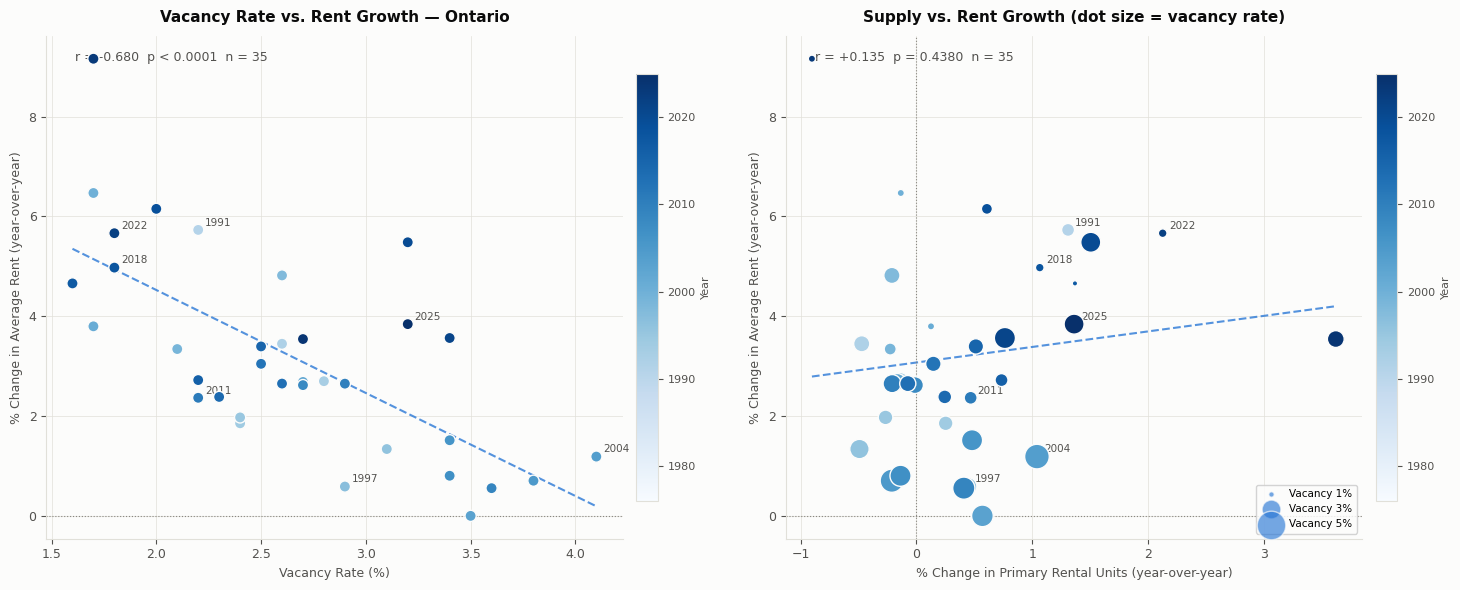

In [16]:
yoy_c = pd.DataFrame({
    'pct_rent':     ontario['Average Rent'].pct_change() * 100,
    'vacancy_rate': ontario['Vacancy Rate'],
    'pct_units':    ontario['Units'].pct_change() * 100,
}).dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ── Plot 1: Vacancy Rate vs Rent Change ──────────────────────────────────────
slope_c1, intercept_c1, r_c1, p_c1, _ = stats.linregress(
    yoy_c['vacancy_rate'], yoy_c['pct_rent'])

sc1 = ax1.scatter(yoy_c['vacancy_rate'], yoy_c['pct_rent'],
                  c=yoy_c.index, cmap='Blues',
                  vmin=yoy_c.index.min() - 15, vmax=yoy_c.index.max(),
                  s=65, zorder=5, edgecolors=SURFACE, linewidths=1.0)

xfit_c1 = np.linspace(yoy_c['vacancy_rate'].min(), yoy_c['vacancy_rate'].max(), 100)
ax1.plot(xfit_c1, slope_c1 * xfit_c1 + intercept_c1,
         color=C1, linewidth=1.5, linestyle='--', alpha=0.8)

for yr in [1991, 1997, 2004, 2011, 2018, 2022, 2025]:
    if yr in yoy_c.index:
        ax1.annotate(str(yr),
                     (yoy_c.loc[yr, 'vacancy_rate'], yoy_c.loc[yr, 'pct_rent']),
                     xytext=(5, 3), textcoords='offset points',
                     fontsize=7.5, color=INK2)

p_str_c1 = f'p = {p_c1:.4f}' if p_c1 >= 0.0001 else 'p < 0.0001'
ax1.text(0.05, 0.97, f'r = {r_c1:+.3f}  {p_str_c1}  n = {len(yoy_c)}',
         transform=ax1.transAxes, va='top', fontsize=9, color=INK2)

cbar1 = fig.colorbar(sc1, ax=ax1, pad=0.02, shrink=0.85)
cbar1.set_label('Year', fontsize=8, color=INK2)
cbar1.ax.tick_params(labelsize=8, colors=INK2)

ax1.axhline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax1.set_xlabel('Vacancy Rate (%)', fontsize=9)
ax1.set_ylabel('% Change in Average Rent (year-over-year)', fontsize=9)
ax1.set_title('Vacancy Rate vs. Rent Growth — Ontario',
              fontsize=11, fontweight='bold', color=INK, pad=10)
ax1.grid()
ax1.tick_params(labelsize=9)

# ── Plot 2: Supply change vs Rent change, dot size = vacancy rate ────────────
vac_min, vac_max = yoy_c['vacancy_rate'].min(), yoy_c['vacancy_rate'].max()
sizes_c2 = 15 + ((yoy_c['vacancy_rate'] - vac_min) / (vac_max - vac_min)) * 300

slope_c2, intercept_c2, r_c2, p_c2, _ = stats.linregress(
    yoy_c['pct_units'], yoy_c['pct_rent'])

sc2 = ax2.scatter(yoy_c['pct_units'], yoy_c['pct_rent'],
                  c=yoy_c.index, cmap='Blues',
                  vmin=yoy_c.index.min() - 15, vmax=yoy_c.index.max(),
                  s=sizes_c2, zorder=5, edgecolors=SURFACE, linewidths=1.0)

xfit_c2 = np.linspace(yoy_c['pct_units'].min(), yoy_c['pct_units'].max(), 100)
ax2.plot(xfit_c2, slope_c2 * xfit_c2 + intercept_c2,
         color=C1, linewidth=1.5, linestyle='--', alpha=0.8)

for yr in [1991, 1997, 2004, 2011, 2018, 2022, 2025]:
    if yr in yoy_c.index:
        ax2.annotate(str(yr),
                     (yoy_c.loc[yr, 'pct_units'], yoy_c.loc[yr, 'pct_rent']),
                     xytext=(5, 3), textcoords='offset points',
                     fontsize=7.5, color=INK2)

p_str_c2 = f'p = {p_c2:.4f}' if p_c2 >= 0.0001 else 'p < 0.0001'
ax2.text(0.05, 0.97, f'r = {r_c2:+.3f}  {p_str_c2}  n = {len(yoy_c)}',
         transform=ax2.transAxes, va='top', fontsize=9, color=INK2)

# Vacancy size legend
for vac_lvl in [1, 3, 5]:
    s = 15 + ((vac_lvl - vac_min) / (vac_max - vac_min)) * 300
    ax2.scatter([], [], s=max(s, 15), color=C1, alpha=0.65,
                edgecolors=SURFACE, linewidths=1.0, label=f'Vacancy {vac_lvl}%')
ax2.legend(loc='lower right', fontsize=7.5, framealpha=0.85)

cbar2 = fig.colorbar(sc2, ax=ax2, pad=0.02, shrink=0.85)
cbar2.set_label('Year', fontsize=8, color=INK2)
cbar2.ax.tick_params(labelsize=8, colors=INK2)

ax2.axhline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax2.axvline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax2.set_xlabel('% Change in Primary Rental Units (year-over-year)', fontsize=9)
ax2.set_ylabel('% Change in Average Rent (year-over-year)', fontsize=9)
ax2.set_title('Supply vs. Rent Growth (dot size = vacancy rate)',
              fontsize=11, fontweight='bold', color=INK, pad=10)
ax2.grid()
ax2.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

In [17]:
# ── Section 3C: summary statistics ───────────────────────────────────────────
_, _, _, _, se_c1 = stats.linregress(yoy_c['vacancy_rate'], yoy_c['pct_rent'])
_, _, _, _, se_c2 = stats.linregress(yoy_c['pct_units'],    yoy_c['pct_rent'])
r_sp_c1, p_sp_c1  = stats.spearmanr(yoy_c['vacancy_rate'], yoy_c['pct_rent'])
r_sp_c2, p_sp_c2  = stats.spearmanr(yoy_c['pct_units'],    yoy_c['pct_rent'])
tc_c = stats.t.ppf(0.975, df=len(yoy_c) - 2)

print('Section 3C — Vacancy Rate & Supply vs Rent Change')
print()
print('  Plot 1: Vacancy Rate vs Rent % Change')
print(f'    Pearson  r = {r_c1:+.3f}  p = {p_c1:.4f}  n = {len(yoy_c)}')
print(f'    Spearman ρ = {r_sp_c1:+.3f}  p = {p_sp_c1:.4f}')
print(f'    OLS slope  = {slope_c1:+.3f} pp rent per 1 pp vacancy')
print(f'                 95% CI [{slope_c1 - tc_c * se_c1:+.3f},  {slope_c1 + tc_c * se_c1:+.3f}]')
print()
print('  Plot 2: Supply % Change vs Rent % Change (dot size = vacancy)')
print(f'    Pearson  r = {r_c2:+.3f}  p = {p_c2:.4f}  n = {len(yoy_c)}')
print(f'    Spearman ρ = {r_sp_c2:+.3f}  p = {p_sp_c2:.4f}')
print(f'    OLS slope  = {slope_c2:+.3f} pp rent per 1 pp supply change')
print(f'                 95% CI [{slope_c2 - tc_c * se_c2:+.3f},  {slope_c2 + tc_c * se_c2:+.3f}]')

Section 3C — Vacancy Rate & Supply vs Rent Change

  Plot 1: Vacancy Rate vs Rent % Change
    Pearson  r = -0.680  p = 0.0000  n = 35
    Spearman ρ = -0.655  p = 0.0000
    OLS slope  = -2.064 pp rent per 1 pp vacancy
                 95% CI [-2.852,  -1.275]

  Plot 2: Supply % Change vs Rent % Change (dot size = vacancy)
    Pearson  r = +0.135  p = 0.4380  n = 35
    Spearman ρ = +0.248  p = 0.1501
    OLS slope  = +0.311 pp rent per 1 pp supply change
                 95% CI [-0.495,  +1.118]


### Section 3C (cont.) — Does the Aggregate Vacancy–Rent Correlation Hold City by City?

The Ontario-level scatter (Plot 1 above) shows r ≈ −0.34 across all years — but
aggregate time-series correlations over 30+ years are prone to long-run trend
confounds: vacancy broadly fell while rents rose, which can inflate the observed r
even if there is no strong causal mechanism year-to-year.

Two stress tests: (1) Does the negative relationship hold *within* individual cities
when we look at each city's own year-to-year history? (2) Does it hold when we pool
city-year observations within a shorter, more homogeneous time window?

/tmp/ipykernel_27627/599336821.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  panel_3c = pd.concat(records, ignore_index=True).rename(columns={'Year': 'year'})


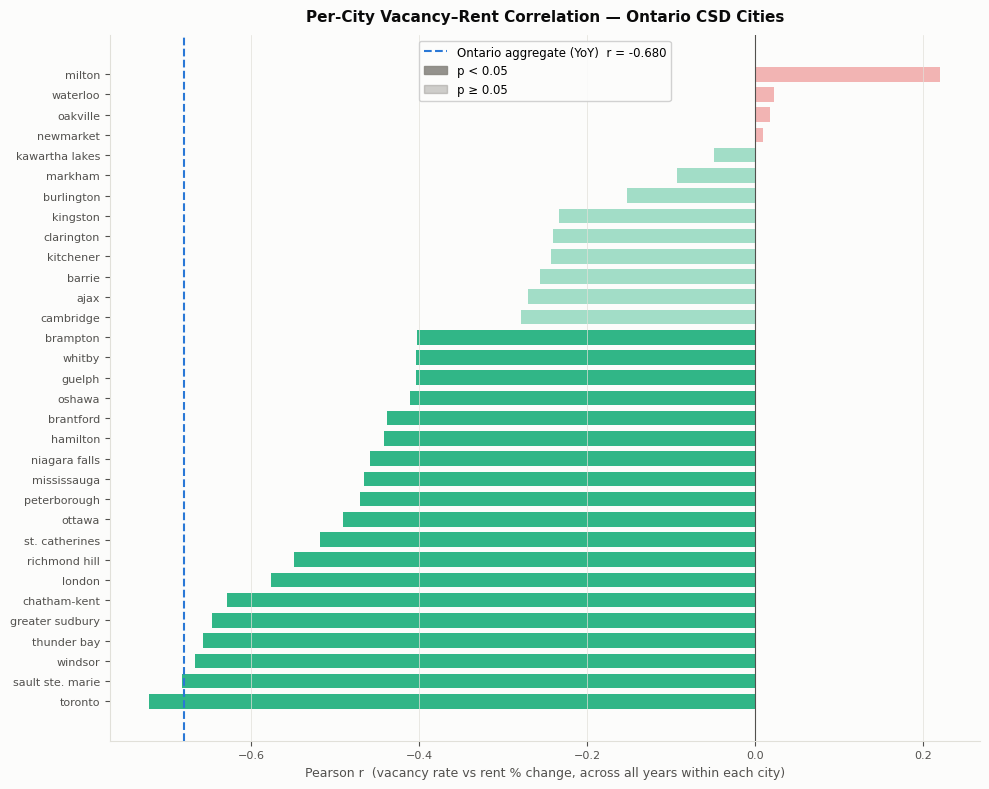

In [18]:
import matplotlib.patches as mpatches

# ── Build city-year panel directly from on-csd primary-summary CSVs ──────────
_CITY_DIR = CLEAN_ROOT / 'on-csd-primary/primary-summary'
records = []
for fp in sorted(_CITY_DIR.glob('*.csv')):
    df = pd.read_csv(fp).set_index('Year')
    if 'Vacancy Rate' not in df.columns or 'Pct Change' not in df.columns:
        continue
    sub = df[['Vacancy Rate', 'Pct Change']].dropna().rename(
        columns={'Vacancy Rate': 'vacancy', 'Pct Change': 'rent_pct'})
    sub['city'] = fp.stem
    records.append(sub.reset_index())
panel_3c = pd.concat(records, ignore_index=True).rename(columns={'Year': 'year'})

# ── Per-city Pearson r (vacancy vs rent_pct across that city's own history) ───
city_r_rows = []
for city, grp in panel_3c.groupby('city'):
    if len(grp) < 6:
        continue
    r_ci, p_ci   = stats.pearsonr(grp['vacancy'],  grp['rent_pct'])
    r_sp_ci, _   = stats.spearmanr(grp['vacancy'], grp['rent_pct'])
    city_r_rows.append({'city': city, 'r': r_ci, 'rho': r_sp_ci, 'p': p_ci, 'n': len(grp)})
city_r = pd.DataFrame(city_r_rows).sort_values('r').reset_index(drop=True)

# Ontario aggregate r (from Section 3C Plot 1 above)
r_ontario_agg = r_c1

# ── Sorted bar chart of per-city r values ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

bar_colors = [C2 if r < 0 else C6 for r in city_r['r']]
bar_alphas = [0.9 if p < 0.05 else 0.40 for p in city_r['p']]

for i, (_, row) in enumerate(city_r.iterrows()):
    ax.barh(i, row['r'], color=bar_colors[i], alpha=bar_alphas[i],
            edgecolor='none', height=0.72)

ax.axvline(0, color=INK2, linewidth=0.8, zorder=3)
ax.axvline(r_ontario_agg, color=C1, linewidth=1.5, linestyle='--', zorder=4,
           label=f'Ontario aggregate (YoY)  r = {r_ontario_agg:.3f}')

ax.set_yticks(range(len(city_r)))
ax.set_yticklabels(city_r['city'], fontsize=7.5)
ax.set_xlabel('Pearson r  (vacancy rate vs rent % change, across all years within each city)', fontsize=9)
ax.set_title('Per-City Vacancy–Rent Correlation — Ontario CSD Cities',
             fontsize=11, fontweight='bold', color=INK, pad=10)

sig_p   = mpatches.Patch(color=MUTED, alpha=0.9,  label='p < 0.05')
insig_p = mpatches.Patch(color=MUTED, alpha=0.40, label='p ≥ 0.05')
handles, lbls = ax.get_legend_handles_labels()
ax.legend(handles + [sig_p, insig_p], lbls + ['p < 0.05', 'p ≥ 0.05'],
          fontsize=8.5, framealpha=0.88)

ax.grid(axis='x')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

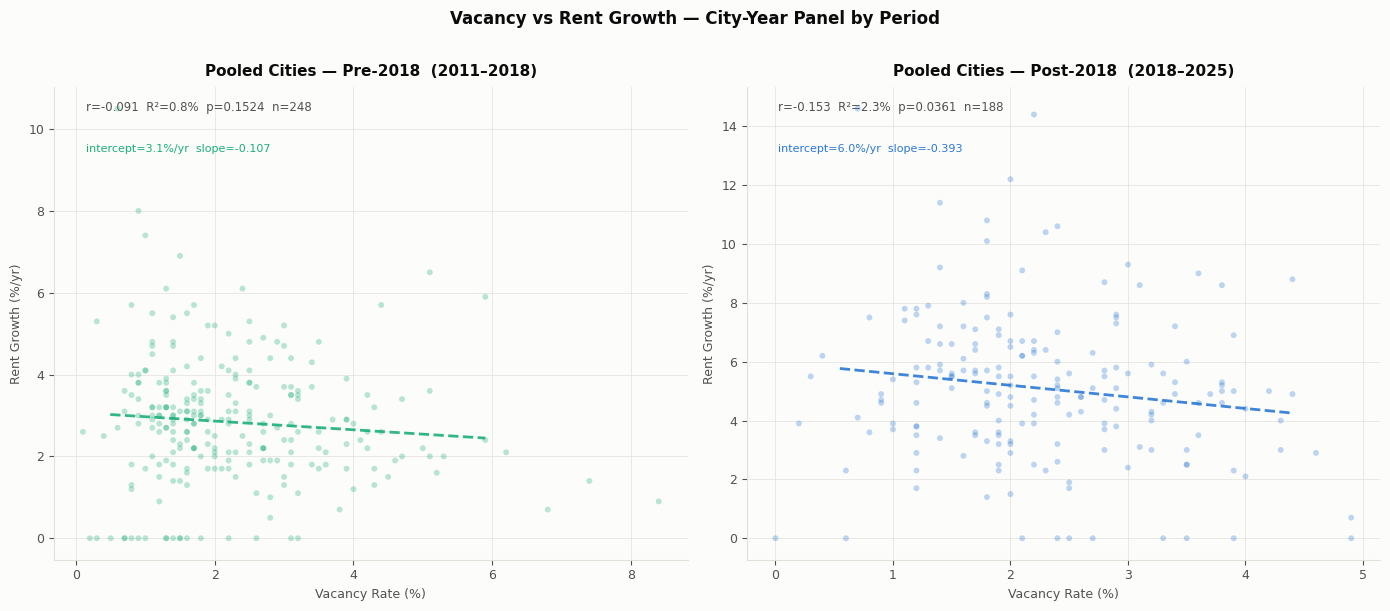

── Per-city time-series r (vacancy vs rent growth within each city's own history)
  28/32 cities show negative r  (88%)
  Significantly negative (p<0.05): 19/32
  Mean per-city r = -0.362  (one-sample t-test: t=-8.510  p=0.0000)
  Sign test (H₀: 50% negative): p = 0.0000

── Within-period cross-sectional r (pooled city-year obs, shorter windows)
  Pre-2018  (2011–2018):  r = -0.091
  Post-2018 (2018–2025):  r = -0.153
  Ontario aggregate YoY:  r = -0.680

Two different questions, two different answers:
  • Within a city's own history: vacancy and rent growth move in opposite
    directions consistently — 28/32 cities confirm this (mean r ≈ −0.36,
    highly significant). The aggregate r has a real signal behind it.
  • Across cities within a single period: which city has higher vacancy
    does not strongly predict which city will have higher rent growth
    (r ≈ −0.13/−0.15). The post-2018 intercept shift (~+3pp baseline)
    suggests structural pressure operating independently of vac

In [19]:
# ── Pooled city-year scatter: pre vs post 2018 ───────────────────────────────
panel_3c['period'] = np.where(
    panel_3c['year'].between(2011, 2018), 'pre_2018',
    np.where(panel_3c['year'].between(2018, 2025), 'post_2018', 'other'))

pre_pool  = panel_3c[panel_3c['period'] == 'pre_2018']
post_pool = panel_3c[panel_3c['period'] == 'post_2018']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (df_p, title, col) in zip(axes, [
    (pre_pool,  'Pooled Cities — Pre-2018  (2011–2018)',  C2),
    (post_pool, 'Pooled Cities — Post-2018  (2018–2025)', C1),
]):
    x, y = df_p['vacancy'], df_p['rent_pct']
    sl, icp, r_pp, p_pp, _ = stats.linregress(x, y)

    ax.scatter(x, y, color=col, s=18, alpha=0.30, edgecolors='none', zorder=5)
    xfit = np.linspace(x.quantile(0.02), x.quantile(0.98), 100)
    ax.plot(xfit, sl * xfit + icp, color=col, linewidth=2.0, linestyle='--', alpha=0.9)

    p_str = f'p={p_pp:.4f}' if p_pp >= 0.0001 else 'p<0.0001'
    ax.text(0.05, 0.97,
            f'r={r_pp:+.3f}  R²={r_pp**2*100:.1f}%  {p_str}  n={len(df_p)}',
            transform=ax.transAxes, va='top', fontsize=8.5, color=INK2)
    ax.text(0.05, 0.88,
            f'intercept={icp:.1f}%/yr  slope={sl:.3f}',
            transform=ax.transAxes, va='top', fontsize=8, color=col)

    ax.set_xlabel('Vacancy Rate (%)', fontsize=9)
    ax.set_ylabel('Rent Growth (%/yr)', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', color=INK, pad=8)
    ax.grid()
    ax.tick_params(labelsize=9)

fig.suptitle('Vacancy vs Rent Growth — City-Year Panel by Period',
             fontsize=12, fontweight='bold', color=INK, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
n_neg     = int((city_r['r'] < 0).sum())
n_sig_neg = int(((city_r['r'] < 0) & (city_r['p'] < 0.05)).sum())
n_tot     = len(city_r)
t_stat_cr, t_p_cr = stats.ttest_1samp(city_r['r'], 0)
binom_neg = stats.binomtest(n_neg, n_tot, 0.5, alternative='greater')

r_pre_pool,  _ = stats.pearsonr(pre_pool['vacancy'],  pre_pool['rent_pct'])
r_post_pool, _ = stats.pearsonr(post_pool['vacancy'], post_pool['rent_pct'])

print('── Per-city time-series r (vacancy vs rent growth within each city\'s own history)')
print(f'  {n_neg}/{n_tot} cities show negative r  ({100*n_neg/n_tot:.0f}%)')
print(f'  Significantly negative (p<0.05): {n_sig_neg}/{n_tot}')
print(f'  Mean per-city r = {city_r["r"].mean():+.3f}  '
      f'(one-sample t-test: t={t_stat_cr:.3f}  p={t_p_cr:.4f})')
print(f'  Sign test (H₀: 50% negative): p = {binom_neg.pvalue:.4f}')
print()
print('── Within-period cross-sectional r (pooled city-year obs, shorter windows)')
print(f'  Pre-2018  (2011–2018):  r = {r_pre_pool:+.3f}')
print(f'  Post-2018 (2018–2025):  r = {r_post_pool:+.3f}')
print(f'  Ontario aggregate YoY:  r = {r_ontario_agg:+.3f}')
print()
print('Two different questions, two different answers:')
print('  • Within a city\'s own history: vacancy and rent growth move in opposite')
print(f'    directions consistently — {n_neg}/{n_tot} cities confirm this (mean r ≈ −0.36,')
print( '    highly significant). The aggregate r has a real signal behind it.')
print('  • Across cities within a single period: which city has higher vacancy')
print(f'    does not strongly predict which city will have higher rent growth')
print(f'    (r ≈ −0.13/−0.15). The post-2018 intercept shift (~+3pp baseline)')
print( '    suggests structural pressure operating independently of vacancy.')

## Section 3D — New Supply vs. Above-Guideline Rent Gap

Each dot is one year (1991–2025).  x = year-over-year % change in primary rental units;
y = how much rent actually rose *above* the Ontario guideline maximum that year
(negative = rent grew slower than the guideline).

If new supply put downward pressure on rent inflation we would expect a negative slope
— more supply growth → smaller excess gap.

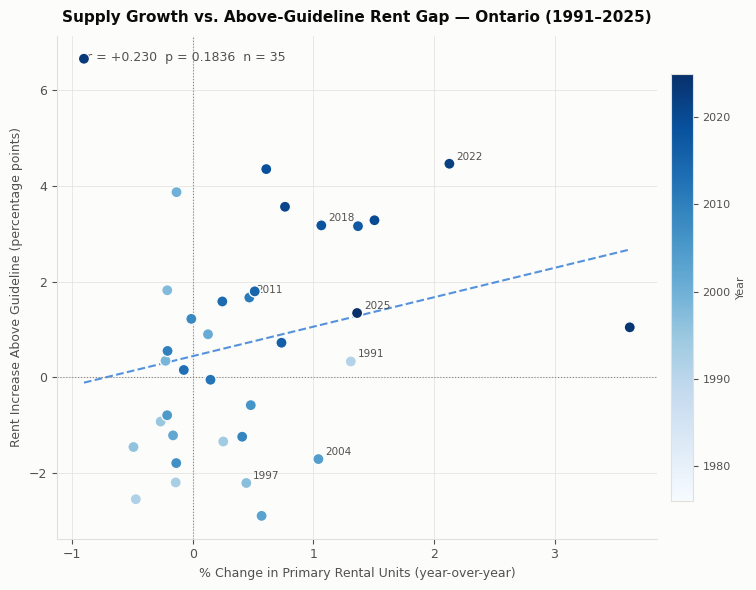

In [20]:
yoy_d = pd.DataFrame({
    'pct_units': ontario['Units'].pct_change() * 100,
    'pct_rent':  ontario['Average Rent'].pct_change() * 100,
}).dropna()

yoy_d['guideline'] = yoy_d.index.map(lambda yr: RENT_CONTROL.get(yr, 0.0))
yoy_d['gap'] = yoy_d['pct_rent'] - yoy_d['guideline']  # pp above guideline

slope_d, intercept_d, r_d, p_d, _ = stats.linregress(yoy_d['pct_units'], yoy_d['gap'])

fig, ax = plt.subplots(figsize=(8, 6))

sc_d = ax.scatter(yoy_d['pct_units'], yoy_d['gap'],
                  c=yoy_d.index, cmap='Blues',
                  vmin=yoy_d.index.min() - 15, vmax=yoy_d.index.max(),
                  s=65, zorder=5, edgecolors=SURFACE, linewidths=1.0)

xfit_d = np.linspace(yoy_d['pct_units'].min(), yoy_d['pct_units'].max(), 100)
ax.plot(xfit_d, slope_d * xfit_d + intercept_d,
        color=C1, linewidth=1.5, linestyle='--', alpha=0.8)

for yr in [1991, 1997, 2004, 2011, 2018, 2022, 2025]:
    if yr in yoy_d.index:
        ax.annotate(str(yr),
                    (yoy_d.loc[yr, 'pct_units'], yoy_d.loc[yr, 'gap']),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=7.5, color=INK2)

p_str_d = f'p = {p_d:.4f}' if p_d >= 0.0001 else 'p < 0.0001'
ax.text(0.05, 0.97, f'r = {r_d:+.3f}  {p_str_d}  n = {len(yoy_d)}',
        transform=ax.transAxes, va='top', fontsize=9, color=INK2)

cbar_d = fig.colorbar(sc_d, ax=ax, pad=0.02, shrink=0.85)
cbar_d.set_label('Year', fontsize=8, color=INK2)
cbar_d.ax.tick_params(labelsize=8, colors=INK2)

ax.axhline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.set_xlabel('% Change in Primary Rental Units (year-over-year)', fontsize=9)
ax.set_ylabel('Rent Increase Above Guideline (percentage points)', fontsize=9)
ax.set_title('Supply Growth vs. Above-Guideline Rent Gap — Ontario (1991–2025)',
             fontsize=11, fontweight='bold', color=INK, pad=10)
ax.grid()
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

In [21]:
# ── Section 3D: summary statistics ───────────────────────────────────────────
_, _, _, _, se_d = stats.linregress(yoy_d['pct_units'], yoy_d['gap'])
r_sp_d, p_sp_d  = stats.spearmanr(yoy_d['pct_units'], yoy_d['gap'])
tc_d = stats.t.ppf(0.975, df=len(yoy_d) - 2)

n_above = int((yoy_d['gap'] > 0).sum())
print('Section 3D — Supply Growth vs Above-Guideline Rent Gap')
print(f'  Pearson  r = {r_d:+.3f}  p = {p_d:.4f}  n = {len(yoy_d)}')
print(f'  Spearman ρ = {r_sp_d:+.3f}  p = {p_sp_d:.4f}')
print(f'  OLS slope  = {slope_d:+.3f} pp gap per 1 pp supply growth')
print(f'               95% CI [{slope_d - tc_d * se_d:+.3f},  {slope_d + tc_d * se_d:+.3f}]')
print()
print(f'  Mean gap: {yoy_d["gap"].mean():+.2f} pp above guideline')
print(f'  Years above guideline: {n_above}/{len(yoy_d)}  ({100 * n_above / len(yoy_d):.0f}%)')

# One-sample t-test: is the mean gap significantly different from zero?
t_gap, p_gap = stats.ttest_1samp(yoy_d['gap'], popmean=0)
print(f'  t-test (gap = 0):  t = {t_gap:+.3f}  p = {p_gap:.4f}')

Section 3D — Supply Growth vs Above-Guideline Rent Gap
  Pearson  r = +0.230  p = 0.1836  n = 35
  Spearman ρ = +0.335  p = 0.0492
  OLS slope  = +0.615 pp gap per 1 pp supply growth
               95% CI [-0.306,  +1.536]

  Mean gap: +0.71 pp above guideline
  Years above guideline: 21/35  (60%)
  t-test (gap = 0):  t = +1.826  p = 0.0766


## Section 4 — Supply and Rent: City Level (Small Multiples)

Each panel is one seven-year period; each dot is an Ontario CSD city.  Dot size
scales with the number of primary rental units at the start of the period
(larger city = bigger dot).  Cities without data for both endpoints of a period
are omitted from that panel.

The dashed line is an OLS fit.  If supply suppressed rents we would expect a
negative slope (more units built → smaller rent increase).

In [22]:
CITY_DIR = CLEAN_ROOT / 'on-csd-primary/primary-summary'

city_data = {}
for fp in tqdm(sorted(CITY_DIR.glob('*.csv'))):
    df = pd.read_csv(fp).set_index('Year')
    city_data[fp.stem] = df


def period_city_df(start_yr: int, end_yr: int) -> pd.DataFrame:
    """Return a df with one row per city that has data at both endpoints."""
    rows = []
    for city, df in city_data.items():
        try:
            r0 = df.loc[start_yr, 'Average Rent']
            r1 = df.loc[end_yr,   'Average Rent']
            u0 = df.loc[start_yr, 'Units']
            u1 = df.loc[end_yr,   'Units']
        except KeyError:
            continue
        if any(pd.isna(v) for v in (r0, r1, u0, u1)) or u0 == 0:
            continue
        rows.append({
            'city':        city,
            'pct_rent':    (r1 - r0) / r0  * 100,
            'pct_units':   (u1 - u0) / u0  * 100,
            'units_start': u0,
        })
    return pd.DataFrame(rows)


period_city_dfs = {f'{s}\u2013{e}': period_city_df(s, e) for s, e in PERIODS}

for label, df in period_city_dfs.items():
    print(f'{label}: {len(df)} cities')

  0%|          | 0/34 [00:00<?, ?it/s]

1990–1997: 24 cities
1997–2004: 25 cities
2004–2011: 32 cities
2011–2018: 32 cities
2018–2025: 32 cities


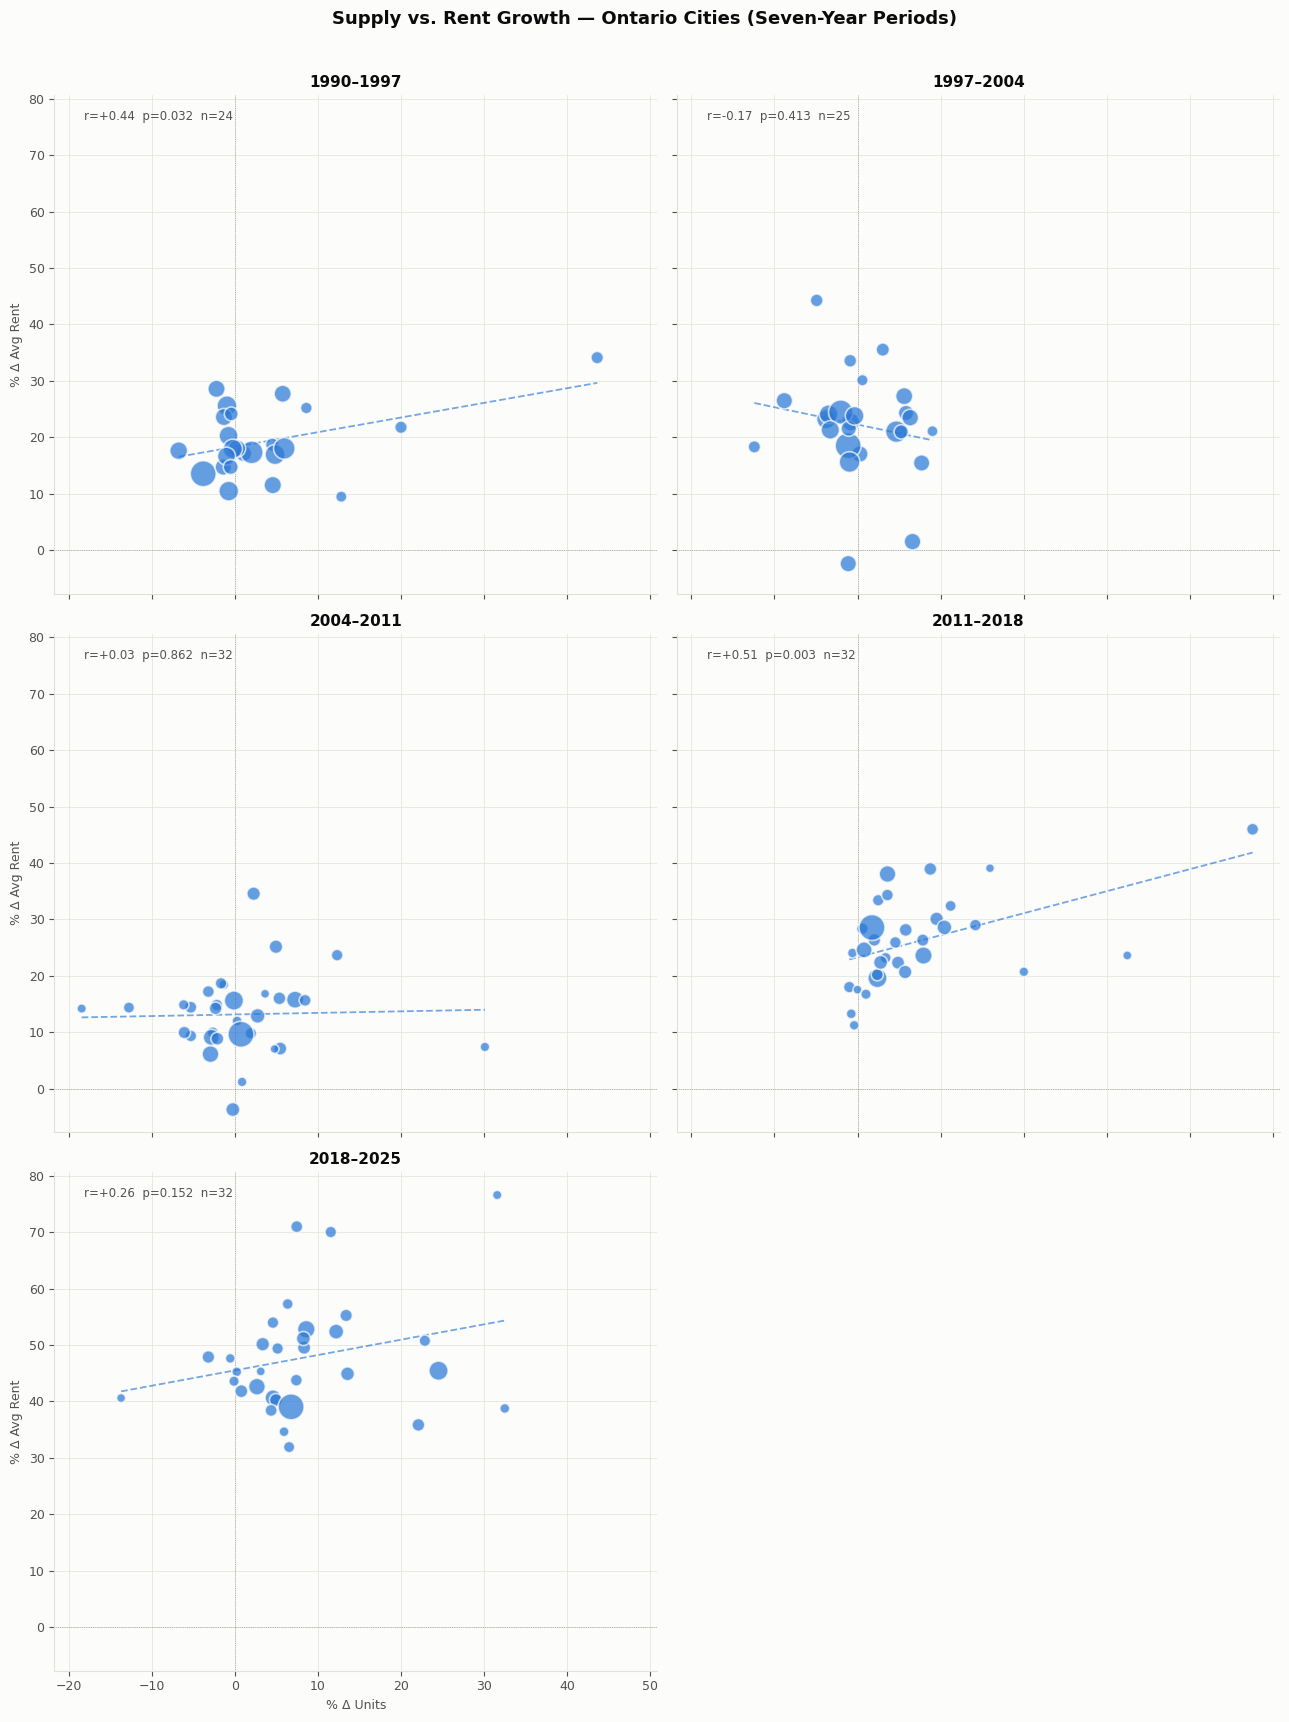

In [23]:
MIN_S, MAX_S = 25, 350

fig, axes = plt.subplots(3, 2, figsize=(13, 17), sharex=True, sharey=True)
axes_flat = axes.flatten()

fig.suptitle('Supply vs. Rent Growth — Ontario Cities (Seven-Year Periods)',
             fontsize=13, fontweight='bold', color=INK, y=1.01)

for i, (ax, (label, df)) in enumerate(zip(axes_flat, period_city_dfs.items())):
    ax.set_title(label, fontsize=11, fontweight='bold', color=INK)

    if df.empty or len(df) < 3:
        ax.text(0.5, 0.5, 'Insufficient data',
                ha='center', va='center', transform=ax.transAxes,
                color=MUTED, fontsize=9)
        continue

    sz = MIN_S + (np.sqrt(df['units_start']) / np.sqrt(df['units_start'].max())) * (MAX_S - MIN_S)

    ax.scatter(df['pct_units'], df['pct_rent'],
               s=sz, color=C1, alpha=0.72,
               edgecolors=SURFACE, linewidths=1.2, zorder=5)

    slope, intercept, r, p, _ = stats.linregress(df['pct_units'], df['pct_rent'])
    xfit = np.linspace(df['pct_units'].min(), df['pct_units'].max(), 100)
    ax.plot(xfit, slope * xfit + intercept,
            color=C1, linewidth=1.3, linestyle='--', alpha=0.65)

    p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
    ax.text(0.05, 0.97, f'r={r:+.2f}  {p_str}  n={len(df)}',
            transform=ax.transAxes, va='top', fontsize=8.5, color=INK2)

    ax.axhline(0, color=MUTED, linewidth=0.5, linestyle=':')
    ax.axvline(0, color=MUTED, linewidth=0.5, linestyle=':')
    ax.grid()
    ax.tick_params(labelsize=9)

# Shared axis labels on outer edges only
for ax in axes[:, 0]:
    ax.set_ylabel('% Δ Avg Rent', fontsize=9, color=INK2)
for ax in axes[-1, :]:
    ax.set_xlabel('% Δ Units', fontsize=9, color=INK2)

# Hide unused 6th panel
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

In [24]:
# Pool all city-period observations for an overall test
pooled = pd.concat(
    [df.assign(period=label) for label, df in period_city_dfs.items()],
    ignore_index=True,
)

r_all,  p_all  = stats.pearsonr(pooled['pct_units'], pooled['pct_rent'])
rs_all, ps_all = stats.spearmanr(pooled['pct_units'], pooled['pct_rent'])
print(f'Pooled (all cities × periods)  n = {len(pooled)}')
print(f'  Pearson  r = {r_all:+.3f}  p = {p_all:.4f}')
print(f'  Spearman ρ = {rs_all:+.3f}  p = {ps_all:.4f}')
print()

# Per-period breakdown: Pearson, Spearman, OLS slope with 95% CI
rows = []
r_vals = []
for label, df in period_city_dfs.items():
    if len(df) < 3:
        rows.append(dict(n=len(df), r=None, rho=None, p=None, slope=None, CI_95='—'))
        continue
    r_p, p_p  = stats.pearsonr(df['pct_units'], df['pct_rent'])
    r_s, _    = stats.spearmanr(df['pct_units'], df['pct_rent'])
    sl, _, _, _, se = stats.linregress(df['pct_units'], df['pct_rent'])
    tc = stats.t.ppf(0.975, df=len(df) - 2)
    r_vals.append(r_p)
    rows.append(dict(
        n     = len(df),
        r     = round(r_p, 3),
        rho   = round(r_s, 3),
        p     = round(p_p, 4),
        slope = round(sl,  3),
        CI_95 = f'[{sl - tc*se:+.3f}, {sl + tc*se:+.3f}]',
    ))

out_df = pd.DataFrame(rows, index=list(period_city_dfs.keys()))
out_df.index.name = 'Period'
print(out_df.to_string())
print()

# Sign test: are negative per-period r values more common than chance?
n_neg = sum(rv < 0 for rv in r_vals)
n_tot = len(r_vals)
binom_res = stats.binomtest(n_neg, n_tot, p=0.5, alternative='greater')
print(f'Sign test  {n_neg}/{n_tot} periods with r < 0  (one-sided p = {binom_res.pvalue:.4f})')
print('H₀: each period equally likely to show positive or negative r')

Pooled (all cities × periods)  n = 145
  Pearson  r = +0.366  p = 0.0000
  Spearman ρ = +0.422  p = 0.0000

            n      r    rho       p  slope             CI_95
Period                                                      
1990–1997  24  0.438  0.159  0.0324  0.260  [+0.024, +0.496]
1997–2004  25 -0.171 -0.170  0.4132 -0.308  [-1.073, +0.457]
2004–2011  32  0.032  0.133  0.8621  0.028  [-0.297, +0.353]
2011–2018  32  0.511  0.552  0.0028  0.390  [+0.145, +0.635]
2018–2025  32  0.259  0.258  0.1520  0.272  [-0.106, +0.650]

Sign test  1/5 periods with r < 0  (one-sided p = 0.9688)
H₀: each period equally likely to show positive or negative r
